# 🏦 Banking Credit Risk & Fraud Detection Analytics

## Notebook 07 — Fraud Detection Modeling

### Objective

The objective of this notebook is to develop machine-learning models capable of identifying fraudulent credit-card transactions.

The target variable is:

`Class`

where:

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

### Dataset

The dataset contains:

- 284,807 transactions
- 492 fraudulent transactions
- 284,315 legitimate transactions

Fraud represents approximately 0.173% of all transactions.

### Key Challenge

The dataset exhibits extreme class imbalance.

The legitimate-to-fraud ratio is approximately:

`577.88 : 1`

Therefore, accuracy alone is not an appropriate metric for evaluating fraud-detection performance.

### Modeling Objectives

This notebook will:

1. Establish a naive baseline.
2. Explore the impact of class imbalance.
3. Prepare the data for modeling.
4. Train multiple classification models.
5. Evaluate precision, recall, F1-score, ROC-AUC, and PR-AUC.
6. Investigate class-weighting strategies.
7. Evaluate appropriate resampling techniques.
8. Tune the strongest candidate model.
9. Optimize the classification threshold.
10. Analyze feature importance and model explainability.
11. Save the final fraud-detection model and preprocessing artifacts.

### Business Context

In fraud detection, failing to identify a fraudulent transaction can result in direct financial loss.

However, incorrectly flagging legitimate transactions can create customer friction, transaction declines, and operational investigation costs.

Therefore, the final model must balance fraud detection capability with false-positive control.

## 1. Import Required Libraries

The following libraries will be used for data preparation, model training, evaluation, cross-validation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

print("Fraud modeling libraries imported successfully.")

Fraud modeling libraries imported successfully.


## 2. Load Fraud Dataset

The fraud transaction dataset is stored in the project's `data/fraud/` directory.

The dataset contains:

- 284,807 transactions
- 31 columns
- `Time`
- PCA-transformed variables `V1` through `V28`
- `Amount`
- `Class`

The target variable is:

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

The dataset will be used to develop and evaluate a machine-learning fraud detection system.

In [2]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
D:\Banking-Credit-Risk-Fraud-Analytics\notebook


In [3]:
print("\nFiles and folders in current directory:")
print(os.listdir())


Files and folders in current directory:
['.ipynb_checkpoints', '01_Data_Understanding.ipynb', '02_Data_Cleaning.ipynb', '03_Exploratory_Data_Analysis.ipynb', '04_Statistical_Analysis.ipynb', '05_Feature_Engineering.ipynb', '06_Credit_Risk_Modeling.ipynb', '07_Fraud_Detection_Modeling.ipynb']


In [4]:
fraud_df = pd.read_csv(
    r"D:\Banking-Credit-Risk-Fraud-Analytics\data\fraud\creditcard.csv"
)

print("Fraud dataset loaded successfully!")
print("Shape:", fraud_df.shape)
print("\nColumns:")
print(fraud_df.columns.tolist())

Fraud dataset loaded successfully!
Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
print(
    fraud_df["Class"].value_counts()
)

print("\nClass proportions:")
print(
    fraud_df["Class"].value_counts(
        normalize=True
    ) * 100
)

Class
0    284315
1       492
Name: count, dtype: int64

Class proportions:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# 6. Fraud Detection Baseline Modeling

The fraud dataset contains an extremely imbalanced target, with fraudulent transactions representing approximately 0.173% of all transactions.

Because of this imbalance, accuracy alone is not an appropriate primary evaluation metric.

A classifier that predicts every transaction as legitimate can achieve approximately 99.83% accuracy while detecting zero fraudulent transactions.

Therefore, the fraud class will be evaluated primarily using:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Particular attention will be given to fraud recall and PR-AUC because the primary objective is to identify rare fraudulent transactions while controlling false-positive alerts.

The first real model will be Logistic Regression, which will establish a baseline before more advanced imbalance-handling techniques are introduced.

## 6.1 Logistic Regression Baseline

Logistic Regression is used as the first machine-learning baseline because it is computationally efficient, interpretable, and produces probability estimates.

The model will initially be trained using the natural class distribution without class weighting.

This provides a reference point for evaluating the impact of subsequent imbalance-handling techniques.

In [6]:
from sklearn.model_selection import train_test_split

X_fraud = fraud_df.drop(
    columns=["Class"]
)

y_fraud = fraud_df["Class"]

X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.20,
    random_state=42,
    stratify=y_fraud
)

print("Training shape:", X_fraud_train.shape)
print("Testing shape :", X_fraud_test.shape)

print("\nTraining class distribution:")
print(y_fraud_train.value_counts())

print("\nTesting class distribution:")
print(y_fraud_test.value_counts())

Training shape: (227845, 30)
Testing shape : (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

fraud_scaler = StandardScaler()

X_fraud_train_scaled = X_fraud_train.copy()
X_fraud_test_scaled = X_fraud_test.copy()

scale_columns = [
    "Time",
    "Amount"
]

X_fraud_train_scaled[scale_columns] = (
    fraud_scaler.fit_transform(
        X_fraud_train[scale_columns]
    )
)

X_fraud_test_scaled[scale_columns] = (
    fraud_scaler.transform(
        X_fraud_test[scale_columns]
    )
)

print("Fraud feature scaling completed.")

Fraud feature scaling completed.


In [8]:
X_fraud_train_scaled[
    ["Time", "Amount"]
].describe()

,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.407707e-16,-2.020811e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


In [9]:
fraud_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

fraud_logistic.fit(
    X_fraud_train_scaled,
    y_fraud_train
)

print(
    "Fraud Logistic Regression trained successfully."
)

Fraud Logistic Regression trained successfully.


In [10]:
y_pred_fraud_lr = fraud_logistic.predict(
    X_fraud_test_scaled
)

y_prob_fraud_lr = fraud_logistic.predict_proba(
    X_fraud_test_scaled
)[:, 1]

print("Fraud predictions generated successfully.")

Fraud predictions generated successfully.


In [11]:
y_pred_fraud_lr = fraud_logistic.predict(
    X_fraud_test_scaled
)

y_prob_fraud_lr = fraud_logistic.predict_proba(
    X_fraud_test_scaled
)[:, 1]

print("Fraud predictions generated successfully.")

Fraud predictions generated successfully.


In [12]:
fraud_lr_metrics = {
    "Accuracy": accuracy_score(
        y_fraud_test,
        y_pred_fraud_lr
    ),
    "Precision": precision_score(
        y_fraud_test,
        y_pred_fraud_lr,
        zero_division=0
    ),
    "Recall": recall_score(
        y_fraud_test,
        y_pred_fraud_lr,
        zero_division=0
    ),
    "F1": f1_score(
        y_fraud_test,
        y_pred_fraud_lr,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_fraud_test,
        y_prob_fraud_lr
    ),
    "PR_AUC": average_precision_score(
        y_fraud_test,
        y_prob_fraud_lr
    )
}

fraud_lr_metrics

{'Accuracy': 0.9991573329588147,
 'Precision': 0.8289473684210527,
 'Recall': 0.6428571428571429,
 'F1': 0.7241379310344828,
 'ROC_AUC': 0.9558983554029378,
 'PR_AUC': 0.7431691767832421}

## 6.2 Confusion Matrix

The confusion matrix provides a detailed view of how the fraud-detection model classifies transactions.

The four outcomes are:

- **True Negative (TN):** Legitimate transaction correctly identified.
- **False Positive (FP):** Legitimate transaction incorrectly flagged as fraud.
- **False Negative (FN):** Fraudulent transaction missed by the model.
- **True Positive (TP):** Fraudulent transaction correctly detected.

In fraud detection, both false negatives and false positives have business consequences.

False negatives represent missed fraudulent transactions, while false positives may result in unnecessary transaction declines, customer friction, or manual investigations.

In [13]:
fraud_lr_cm = confusion_matrix(
    y_fraud_test,
    y_pred_fraud_lr
)

print(fraud_lr_cm)

print("\nTN:", fraud_lr_cm[0, 0])
print("FP:", fraud_lr_cm[0, 1])
print("FN:", fraud_lr_cm[1, 0])
print("TP:", fraud_lr_cm[1, 1])

[[56851    13]
 [   35    63]]

TN: 56851
FP: 13
FN: 35
TP: 63


In [14]:
print(
    classification_report(
        y_fraud_test,
        y_pred_fraud_lr,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Class-Weighted Logistic Regression

The fraud class is severely underrepresented in the dataset.

To give fraudulent transactions greater influence during model training, a class-weighted Logistic Regression model will be trained using:

`class_weight="balanced"`

This approach does not generate synthetic observations.

Instead, it increases the relative importance of minority-class observations during optimization.

The weighted model will be compared with the standard Logistic Regression model to determine whether fraud detection improves and how the precision-recall trade-off changes.

In [15]:
fraud_weighted_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

fraud_weighted_lr.fit(
    X_fraud_train_scaled,
    y_fraud_train
)

print(
    "Weighted Fraud Logistic Regression trained successfully."
)

Weighted Fraud Logistic Regression trained successfully.


In [16]:
y_pred_fraud_weighted = (
    fraud_weighted_lr.predict(
        X_fraud_test_scaled
    )
)

y_prob_fraud_weighted = (
    fraud_weighted_lr.predict_proba(
        X_fraud_test_scaled
    )[:, 1]
)

print(
    "Weighted fraud predictions generated successfully."
)

Weighted fraud predictions generated successfully.


In [17]:
fraud_weighted_metrics = {
    "Accuracy": accuracy_score(
        y_fraud_test,
        y_pred_fraud_weighted
    ),
    "Precision": precision_score(
        y_fraud_test,
        y_pred_fraud_weighted,
        zero_division=0
    ),
    "Recall": recall_score(
        y_fraud_test,
        y_pred_fraud_weighted,
        zero_division=0
    ),
    "F1": f1_score(
        y_fraud_test,
        y_pred_fraud_weighted,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_fraud_test,
        y_prob_fraud_weighted
    ),
    "PR_AUC": average_precision_score(
        y_fraud_test,
        y_prob_fraud_weighted
    )
}

fraud_weighted_metrics

{'Accuracy': 0.9755275446789088,
 'Precision': 0.06097560975609756,
 'Recall': 0.9183673469387755,
 'F1': 0.11435832274459974,
 'ROC_AUC': 0.9721687370080279,
 'PR_AUC': 0.7159122424484009}

In [18]:
fraud_lr_comparison = pd.DataFrame(
    [
        fraud_lr_metrics,
        fraud_weighted_metrics
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression"
    ]
)

fraud_lr_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.999157,0.828947,0.642857,0.724138,0.955898,0.743169
Weighted Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972169,0.715912


In [19]:
weighted_cm = confusion_matrix(
    y_fraud_test,
    y_pred_fraud_weighted
)

print("Standard Logistic Regression")
print(fraud_lr_cm)

print("\nWeighted Logistic Regression")
print(weighted_cm)

Standard Logistic Regression
[[56851    13]
 [   35    63]]

Weighted Logistic Regression
[[55478  1386]
 [    8    90]]


In [20]:
fraud_cases = y_fraud_test.sum()

standard_tp = fraud_lr_cm[1, 1]
weighted_tp = weighted_cm[1, 1]

print("Actual fraud cases:", fraud_cases)

print(
    "Standard LR fraud cases detected:",
    standard_tp
)

print(
    "Weighted LR fraud cases detected:",
    weighted_tp
)

Actual fraud cases: 98
Standard LR fraud cases detected: 63
Weighted LR fraud cases detected: 90


## 7.1 Logistic Regression Findings

The standard Logistic Regression model establishes the baseline performance under the natural class distribution.

The class-weighted Logistic Regression model gives greater importance to fraudulent transactions during training.

The comparison highlights the trade-off between:

- Fraud recall
- Precision
- False-positive alerts
- F1-score

An increase in fraud recall may result in more false-positive alerts.

Therefore, the weighted model should not automatically be considered superior simply because it detects more fraud cases.

The models will be compared using fraud-class performance and PR-AUC before selecting a candidate for further development.

Tree-based models will next be evaluated to determine whether nonlinear patterns and feature interactions can improve fraud detection.

In [21]:
fraud_lr_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.999157,0.828947,0.642857,0.724138,0.955898,0.743169
Weighted Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972169,0.715912


## 7.1 Logistic Regression Findings

The standard Logistic Regression model achieved an accuracy of approximately **99.92%**, with a fraud precision of approximately **82.89%** and fraud recall of approximately **64.29%**.

The class-weighted Logistic Regression model substantially increased fraud recall to approximately **91.84%**.

However, this improvement came with a significant reduction in precision, which decreased to approximately **6.10%**.

The weighted model therefore identifies more fraudulent transactions but generates substantially more false-positive alerts.

The standard Logistic Regression model also achieved a higher PR-AUC than the weighted model in this experiment:

- Standard Logistic Regression PR-AUC: **0.743**
- Weighted Logistic Regression PR-AUC: **0.716**

### Conclusion

Class weighting successfully increases sensitivity toward the minority fraud class, but the resulting false-positive rate makes the default 0.50 classification threshold unsuitable for direct operational use.

Further investigation using tree-based models and classification-threshold optimization is required.

# 8. Random Forest Fraud Detection

Random Forest is an ensemble learning method that combines predictions from multiple decision trees.

Compared with Logistic Regression, Random Forest can capture:

- Nonlinear relationships
- Feature interactions
- Complex decision boundaries

A class-weighted Random Forest will initially be evaluated because of the extreme imbalance in the fraud dataset.

The model will be evaluated using the same metrics as the Logistic Regression models.

Accuracy will remain a secondary metric.

In [22]:
fraud_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

fraud_rf.fit(
    X_fraud_train_scaled,
    y_fraud_train
)

print(
    "Fraud Random Forest trained successfully."
)

Fraud Random Forest trained successfully.


In [23]:
y_pred_fraud_rf = fraud_rf.predict(
    X_fraud_test_scaled
)

y_prob_fraud_rf = fraud_rf.predict_proba(
    X_fraud_test_scaled
)[:, 1]

print(
    "Random Forest fraud predictions generated."
)

Random Forest fraud predictions generated.


In [24]:
fraud_rf_metrics = {
    "Accuracy": accuracy_score(
        y_fraud_test,
        y_pred_fraud_rf
    ),
    "Precision": precision_score(
        y_fraud_test,
        y_pred_fraud_rf,
        zero_division=0
    ),
    "Recall": recall_score(
        y_fraud_test,
        y_pred_fraud_rf,
        zero_division=0
    ),
    "F1": f1_score(
        y_fraud_test,
        y_pred_fraud_rf,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_fraud_test,
        y_prob_fraud_rf
    ),
    "PR_AUC": average_precision_score(
        y_fraud_test,
        y_prob_fraud_rf
    )
}

fraud_rf_metrics

{'Accuracy': 0.9993328885923949,
 'Precision': 0.8,
 'Recall': 0.8163265306122449,
 'F1': 0.8080808080808081,
 'ROC_AUC': 0.9805055815235492,
 'PR_AUC': 0.8372434527178041}

In [25]:
fraud_rf_cm = confusion_matrix(
    y_fraud_test,
    y_pred_fraud_rf
)

print(fraud_rf_cm)

print("\nTN:", fraud_rf_cm[0, 0])
print("FP:", fraud_rf_cm[0, 1])
print("FN:", fraud_rf_cm[1, 0])
print("TP:", fraud_rf_cm[1, 1])

[[56844    20]
 [   18    80]]

TN: 56844
FP: 20
FN: 18
TP: 80


In [26]:
print(
    classification_report(
        y_fraud_test,
        y_pred_fraud_rf,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.80      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
fraud_model_comparison = pd.DataFrame(
    [
        fraud_lr_metrics,
        fraud_weighted_metrics,
        fraud_rf_metrics
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest"
    ]
)

fraud_model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.999157,0.828947,0.642857,0.724138,0.955898,0.743169
Weighted Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972169,0.715912
Random Forest,0.999333,0.800000,0.816327,0.808081,0.980506,0.837243


In [28]:
fraud_model_comparison.sort_values(
    by="PR_AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Random Forest,0.999333,0.800000,0.816327,0.808081,0.980506,0.837243
Logistic Regression,0.999157,0.828947,0.642857,0.724138,0.955898,0.743169
Weighted Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972169,0.715912


## 8.1 Random Forest Findings

Random Forest substantially improves fraud-detection performance compared with the Logistic Regression baselines.

The model achieved:

- Accuracy: **99.93%**
- Precision: **80.00%**
- Recall: **81.63%**
- F1-score: **80.81%**
- ROC-AUC: **98.05%**
- PR-AUC: **83.72%**

Compared with standard Logistic Regression, Random Forest improves fraud recall from approximately 64.29% to 81.63% and improves F1-score from approximately 72.41% to 80.81%.

PR-AUC also improves from approximately 0.743 to 0.837.

The class-weighted Logistic Regression model achieved higher fraud recall, but its precision decreased substantially to approximately 6.10%.

Random Forest therefore currently provides the strongest balance between fraud detection and false-positive control.

However, additional validation and threshold analysis are required before selecting the final production candidate.

# 9. Cross-Validation for Fraud Detection

A single train-test split provides only one estimate of model performance.

Because fraudulent transactions are extremely rare, performance can vary depending on which observations are included in the training and testing sets.

Stratified K-Fold Cross-Validation will therefore be used to evaluate model stability.

Stratification is important because each fold should maintain approximately the same proportion of fraudulent and legitimate transactions.

The test set will remain untouched.

Cross-validation will be performed only on the training data.

In [29]:
fraud_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    "5-fold stratified cross-validation created."
)

5-fold stratified cross-validation created.


In [30]:
fraud_rf_cv = cross_validate(
    fraud_rf,
    X_fraud_train_scaled,
    y_fraud_train,
    cv=fraud_cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

print("Random Forest cross-validation completed.")

Random Forest cross-validation completed.


In [31]:
fraud_rf_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    
    "Mean": [
        fraud_rf_cv["test_accuracy"].mean(),
        fraud_rf_cv["test_precision"].mean(),
        fraud_rf_cv["test_recall"].mean(),
        fraud_rf_cv["test_f1"].mean(),
        fraud_rf_cv["test_roc_auc"].mean(),
        fraud_rf_cv["test_pr_auc"].mean()
    ],
    
    "Std": [
        fraud_rf_cv["test_accuracy"].std(),
        fraud_rf_cv["test_precision"].std(),
        fraud_rf_cv["test_recall"].std(),
        fraud_rf_cv["test_f1"].std(),
        fraud_rf_cv["test_roc_auc"].std(),
        fraud_rf_cv["test_pr_auc"].std()
    ]
})

fraud_rf_cv_summary

,Metric,Mean,Std
0,Accuracy,0.999425,0.000045
1,Precision,0.874095,0.025065
2,Recall,0.781792,0.040815
3,F1,0.824227,0.017209
4,ROC_AUC,0.980212,0.010894
5,PR_AUC,0.828419,0.023930


## 9.1 Random Forest Cross-Validation Findings

Cross-validation is used to determine whether Random Forest maintains consistent performance across different subsets of the training data.

The mean represents average performance across the five folds.

The standard deviation indicates how much performance varies between folds.

A model with strong average PR-AUC, recall, and F1-score combined with relatively low variability provides stronger evidence of stable performance.

The cross-validation results will be compared with the holdout-test results before final model selection.

# 10. SMOTE-Based Fraud Detection

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic minority-class observations rather than simply duplicating existing fraud transactions.

Because fraud represents only approximately 0.173% of the dataset, SMOTE can potentially provide additional minority-class training information.

However, SMOTE must be applied only to the training data.

### Correct Workflow

Original Dataset
        ↓
Train-Test Split
        ↓
Training Data
        ↓
SMOTE
        ↓
Resampled Training Data
        ↓
Model Training
        ↓
Untouched Test Data

Applying SMOTE before the train-test split would allow synthetic information derived from observations related to the test set to influence training, resulting in data leakage and overly optimistic performance estimates.

SMOTE will therefore be evaluated as a controlled experiment rather than automatically assumed to improve the model.

In [32]:
%pip install imbalanced-learn

     ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
     --- --------------------------------- 20.5/236.1 kB 330.3 kB/s eta 0:00:01
     --- --------------------------------- 20.5/236.1 kB 330.3 kB/s eta 0:00:01
     ------------ ------------------------ 81.9/236.1 kB 573.4 kB/s eta 0:00:01
     ------------------------------- ------ 194.6/236.1 kB 1.2 MB/s eta 0:00:01
     -------------------------------------- 236.1/236.1 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn is available.")
    
except ImportError:
    print(
        "imbalanced-learn is not installed."
    )

imbalanced-learn is available.


In [34]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [35]:
smote = SMOTE(
    random_state=42
)

X_fraud_train_smote, y_fraud_train_smote = (
    smote.fit_resample(
        X_fraud_train_scaled,
        y_fraud_train
    )
)

print(
    "Original training distribution:"
)

print(
    y_fraud_train.value_counts()
)

print(
    "\nSMOTE training distribution:"
)

print(
    y_fraud_train_smote.value_counts()
)

Original training distribution:
Class
0    227451
1       394
Name: count, dtype: int64

SMOTE training distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [36]:
fraud_rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

fraud_rf_smote.fit(
    X_fraud_train_smote,
    y_fraud_train_smote
)

print(
    "SMOTE Random Forest trained successfully."
)

SMOTE Random Forest trained successfully.


In [37]:
y_pred_fraud_smote = (
    fraud_rf_smote.predict(
        X_fraud_test_scaled
    )
)

y_prob_fraud_smote = (
    fraud_rf_smote.predict_proba(
        X_fraud_test_scaled
    )[:, 1]
)

fraud_smote_metrics = {
    "Accuracy": accuracy_score(
        y_fraud_test,
        y_pred_fraud_smote
    ),
    "Precision": precision_score(
        y_fraud_test,
        y_pred_fraud_smote,
        zero_division=0
    ),
    "Recall": recall_score(
        y_fraud_test,
        y_pred_fraud_smote,
        zero_division=0
    ),
    "F1": f1_score(
        y_fraud_test,
        y_pred_fraud_smote,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_fraud_test,
        y_prob_fraud_smote
    ),
    "PR_AUC": average_precision_score(
        y_fraud_test,
        y_prob_fraud_smote
    )
}

fraud_smote_metrics

{'Accuracy': 0.9978757768336786,
 'Precision': 0.4397905759162304,
 'Recall': 0.8571428571428571,
 'F1': 0.5813148788927336,
 'ROC_AUC': 0.9826778787626474,
 'PR_AUC': 0.8111894727241902}

In [38]:
fraud_rf_smote_comparison = pd.DataFrame(
    [
        fraud_rf_metrics,
        fraud_smote_metrics
    ],
    index=[
        "Random Forest",
        "SMOTE Random Forest"
    ]
)

fraud_rf_smote_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Random Forest,0.999333,0.800000,0.816327,0.808081,0.980506,0.837243
SMOTE Random Forest,0.997876,0.439791,0.857143,0.581315,0.982678,0.811189


## 10.1 SMOTE Experiment Findings

SMOTE was evaluated as an alternative approach for handling the extreme class imbalance.

The SMOTE Random Forest model increased fraud recall from approximately **81.63% to 85.71%**.

However, this improvement came with a substantial decrease in fraud precision:

- Random Forest precision: **80.00%**
- SMOTE Random Forest precision: **43.98%**

The F1-score also decreased:

- Random Forest F1: **80.81%**
- SMOTE Random Forest F1: **58.13%**

PR-AUC decreased from approximately **0.837 to 0.811**.

Although ROC-AUC increased slightly, PR-AUC is particularly informative for this highly imbalanced fraud-detection problem.

### Conclusion

SMOTE did not provide an overall improvement in this experiment.

The original Random Forest currently provides a better balance between fraud recall, precision, F1-score, and PR-AUC.

Therefore, the original Random Forest will remain the leading candidate for subsequent threshold optimization and final evaluation.

# 11. Precision-Recall Analysis

Because fraudulent transactions represent only approximately 0.173% of the dataset, the Precision-Recall curve is particularly important.

The curve illustrates the trade-off between fraud precision and fraud recall across different classification thresholds.

The Precision-Recall curves for:

- Logistic Regression
- Random Forest
- SMOTE Random Forest

will be compared.

PR-AUC will be used as a summary measure of ranking performance.

In [40]:
from sklearn.metrics import precision_recall_curve

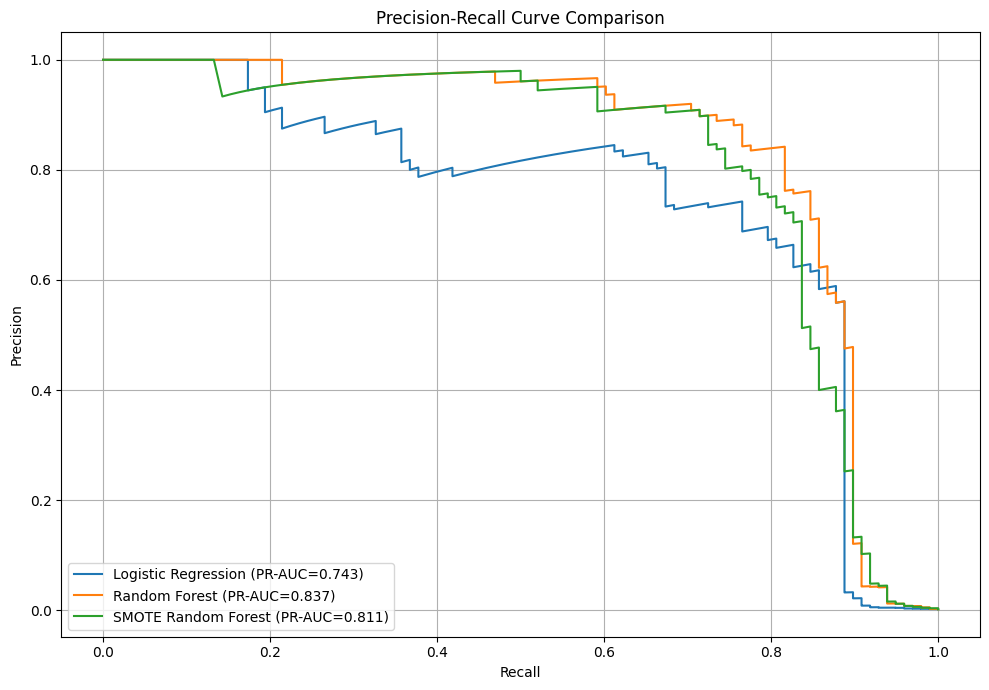

In [41]:
plt.figure(figsize=(10, 7))

precision_lr, recall_lr, _ = precision_recall_curve(
    y_fraud_test,
    y_prob_fraud_lr
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_fraud_test,
    y_prob_fraud_rf
)

precision_smote, recall_smote, _ = precision_recall_curve(
    y_fraud_test,
    y_prob_fraud_smote
)

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (PR-AUC={fraud_lr_metrics['PR_AUC']:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (PR-AUC={fraud_rf_metrics['PR_AUC']:.3f})"
)

plt.plot(
    recall_smote,
    precision_smote,
    label=f"SMOTE Random Forest (PR-AUC={fraud_smote_metrics['PR_AUC']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13. Fraud Classification Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for fraud detection.

A lower threshold can increase fraud recall but may also increase false-positive alerts.

A higher threshold can improve precision but may allow more fraudulent transactions to remain undetected.

Because fraud detection involves a trade-off between missed fraud and false-positive investigation costs, the classification threshold should be evaluated rather than automatically accepting 0.50.

The Random Forest probability scores will therefore be evaluated across a range of thresholds.

The objective of this analysis is to identify a threshold that provides an appropriate balance between precision and recall.

In [42]:
fraud_thresholds = np.arange(
    0.01,
    0.91,
    0.01
)

fraud_threshold_results = []

for threshold in fraud_thresholds:

    threshold_prediction = (
        y_prob_fraud_rf >= threshold
    ).astype(int)

    fraud_threshold_results.append({
        "Threshold": round(threshold, 2),

        "Precision": precision_score(
            y_fraud_test,
            threshold_prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_fraud_test,
            threshold_prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_fraud_test,
            threshold_prediction,
            zero_division=0
        )
    })

fraud_threshold_df = pd.DataFrame(
    fraud_threshold_results
)

fraud_threshold_df.head(10)

,Threshold,Precision,Recall,F1
0,0.01,0.004512,0.989796,0.008983
1,0.02,0.011126,0.959184,0.021996
2,0.03,0.020349,0.938776,0.039835
3,0.04,0.032145,0.938776,0.062162
4,0.05,0.043670,0.908163,0.083333
5,0.06,0.058322,0.908163,0.109606
6,0.07,0.075232,0.908163,0.138954
7,0.08,0.094480,0.908163,0.171154
8,0.09,0.114691,0.908163,0.203661
9,0.10,0.137072,0.897959,0.237838


In [43]:
best_fraud_threshold_row = (
    fraud_threshold_df.loc[
        fraud_threshold_df["F1"].idxmax()
    ]
)

best_fraud_threshold_row

Threshold    0.530000
Precision    0.833333
Recall       0.816327
F1           0.824742
Name: 52, dtype: float64

In [44]:
best_fraud_threshold = (
    best_fraud_threshold_row["Threshold"]
)

print(
    "Best F1 threshold:",
    best_fraud_threshold
)

print(
    "Precision:",
    best_fraud_threshold_row["Precision"]
)

print(
    "Recall:",
    best_fraud_threshold_row["Recall"]
)

print(
    "F1:",
    best_fraud_threshold_row["F1"]
)

Best F1 threshold: 0.53
Precision: 0.8333333333333334
Recall: 0.8163265306122449
F1: 0.8247422680412371


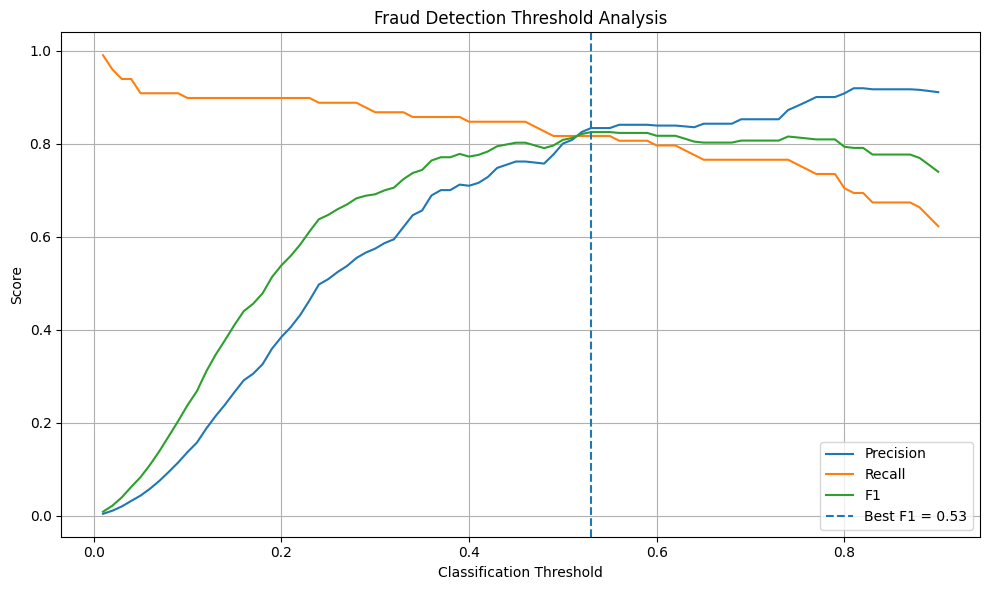

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    fraud_threshold_df["Threshold"],
    fraud_threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    fraud_threshold_df["Threshold"],
    fraud_threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    fraud_threshold_df["Threshold"],
    fraud_threshold_df["F1"],
    label="F1"
)

plt.axvline(
    best_fraud_threshold,
    linestyle="--",
    label=f"Best F1 = {best_fraud_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Fraud Detection Threshold Analysis"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
y_pred_fraud_final = (
    y_prob_fraud_rf >= best_fraud_threshold
).astype(int)

fraud_final_cm = confusion_matrix(
    y_fraud_test,
    y_pred_fraud_final
)

print(fraud_final_cm)

print("\nTN:", fraud_final_cm[0, 0])
print("FP:", fraud_final_cm[0, 1])
print("FN:", fraud_final_cm[1, 0])
print("TP:", fraud_final_cm[1, 1])

[[56848    16]
 [   18    80]]

TN: 56848
FP: 16
FN: 18
TP: 80


In [47]:
fraud_final_metrics = {
    "Threshold": best_fraud_threshold,

    "Accuracy": accuracy_score(
        y_fraud_test,
        y_pred_fraud_final
    ),

    "Precision": precision_score(
        y_fraud_test,
        y_pred_fraud_final,
        zero_division=0
    ),

    "Recall": recall_score(
        y_fraud_test,
        y_pred_fraud_final,
        zero_division=0
    ),

    "F1": f1_score(
        y_fraud_test,
        y_pred_fraud_final,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_fraud_test,
        y_prob_fraud_rf
    ),

    "PR_AUC": average_precision_score(
        y_fraud_test,
        y_prob_fraud_rf
    )
}

fraud_final_metrics

{'Threshold': np.float64(0.53),
 'Accuracy': 0.999403110845827,
 'Precision': 0.8333333333333334,
 'Recall': 0.8163265306122449,
 'F1': 0.8247422680412371,
 'ROC_AUC': 0.9805055815235492,
 'PR_AUC': 0.8372434527178041}

## 13.1 Threshold Optimization Findings

The default 0.50 classification threshold was compared with alternative thresholds using the Random Forest probability estimates.

Threshold optimization demonstrates that precision and recall are inversely related.

Lower thresholds generally increase fraud recall by classifying more transactions as potential fraud, while higher thresholds generally increase precision by requiring stronger evidence before flagging a transaction.

The threshold selected using maximum F1-score provides a data-driven operating point that balances precision and recall.

However, this threshold should not automatically be treated as the final production threshold.

In a real banking environment, the final threshold should incorporate the relative business costs of:

- Missed fraudulent transactions
- False-positive alerts
- Manual investigation
- Customer friction
- Transaction declines

Therefore, the F1-optimized threshold is considered a model-development operating point rather than a universal business rule.

# 14. Final Fraud Model Selection

The candidate fraud-detection models were evaluated using multiple performance measures.

The primary metrics considered are:

- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC

Accuracy is treated as a secondary metric because of the extreme class imbalance.

Based on the experiments performed so far, the original Random Forest model is the leading candidate.

Random Forest achieved a PR-AUC of approximately **0.837**, compared with approximately **0.743** for standard Logistic Regression and **0.811** for the SMOTE Random Forest.

SMOTE increased recall slightly but substantially reduced precision and F1-score.

The Random Forest probability threshold was subsequently optimized to investigate whether a better precision-recall operating point could be achieved.

The final production candidate will therefore consist of:

1. Random Forest model
2. Selected classification threshold
3. Feature-scaling transformation

In [49]:
final_fraud_summary = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    
    "Value": [
        fraud_final_metrics["Threshold"],
        fraud_final_metrics["Accuracy"],
        fraud_final_metrics["Precision"],
        fraud_final_metrics["Recall"],
        fraud_final_metrics["F1"],
        fraud_final_metrics["ROC_AUC"],
        fraud_final_metrics["PR_AUC"]
    ]
})

final_fraud_summary

,Metric,Value
0,Threshold,0.530000
1,Accuracy,0.999403
2,Precision,0.833333
3,Recall,0.816327
4,F1,0.824742
5,ROC_AUC,0.980506
6,PR_AUC,0.837243


# 15. Fraud Model Feature Importance

Feature importance provides a global view of which features contribute most to the Random Forest's decision-making process.

The importance values represent the relative contribution of each feature to the model's tree-based splitting decisions.

Because the transaction variables `V1` through `V28` are anonymized PCA-derived features, their business meaning is not directly available.

Therefore, feature importance will be interpreted as model-level evidence rather than causal evidence about the underlying transaction characteristics.

In [50]:
fraud_feature_importance = pd.DataFrame({
    "Feature": X_fraud_train.columns,
    "Importance": fraud_rf.feature_importances_
})

fraud_feature_importance = (
    fraud_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

fraud_feature_importance.head(15)

,Feature,Importance
0,V14,0.170519
1,V4,0.119188
2,V10,0.118555
3,V12,0.099006
4,V17,0.082341
5,V11,0.065818
6,V3,0.057245
7,V16,0.051946
8,V7,0.029263
9,V2,0.026845


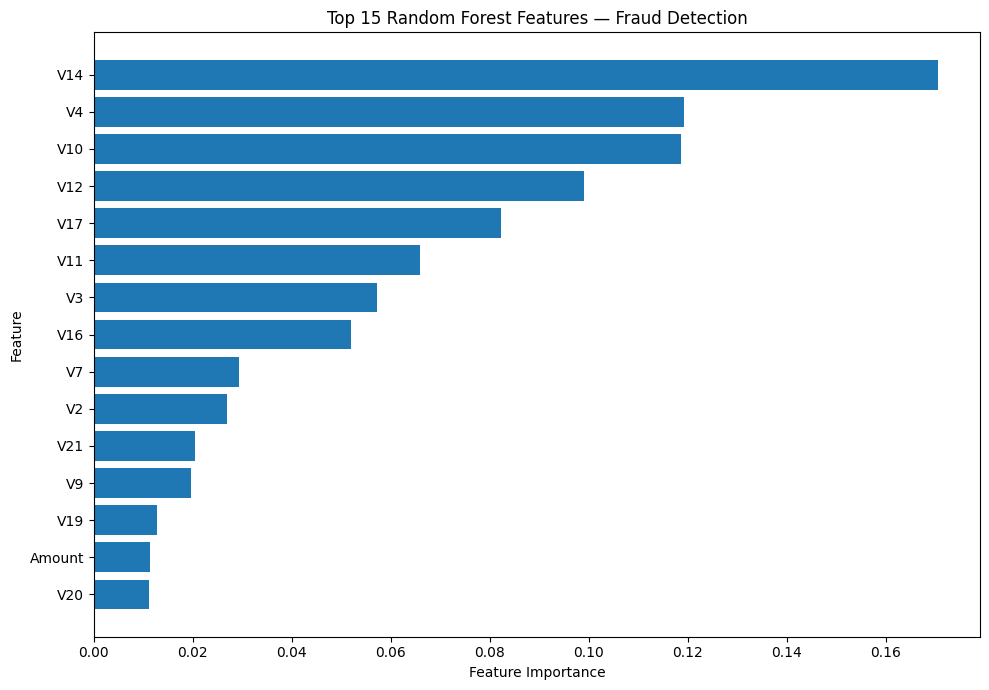

In [51]:
top_fraud_features = (
    fraud_feature_importance
    .head(15)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_fraud_features["Feature"],
    top_fraud_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Random Forest Features — Fraud Detection"
)

plt.tight_layout()
plt.show()

## 15.1 Feature Importance Findings

The Random Forest feature-importance analysis identifies the variables that contribute most strongly to the model's tree-based decisions.

Because the majority of the transaction variables are anonymized PCA-derived features, the importance rankings cannot be directly translated into specific business characteristics.

The results should therefore be interpreted as evidence of which transformed variables are most useful to the model rather than as causal explanations for fraudulent behavior.

Feature importance will be complemented with SHAP analysis to provide a more detailed interpretation of model predictions.

# 16. Fraud Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) will be used to investigate how individual features influence fraud predictions.

Two levels of explanation will be considered:

### Global Explainability

Identifies features that have the greatest overall influence on fraud predictions.

### Local Explainability

Explains why the model assigned a particular transaction a higher or lower fraud probability.

SHAP provides model explanations but does not establish causal relationships between transaction features and fraudulent behavior.

In [52]:
import shap

fraud_shap_explainer = shap.TreeExplainer(
    fraud_rf
)

print(
    "Fraud SHAP explainer created successfully."
)

Fraud SHAP explainer created successfully.


C:\Users\ELCOT\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
shap_sample_size = min(
    2000,
    len(X_fraud_test_scaled)
)

X_fraud_shap_sample = (
    X_fraud_test_scaled
    .sample(
        n=shap_sample_size,
        random_state=42
    )
)

fraud_shap_values = (
    fraud_shap_explainer.shap_values(
        X_fraud_shap_sample
    )
)

print(
    "SHAP sample size:",
    shap_sample_size
)

SHAP sample size: 2000


In [54]:
print(
    type(fraud_shap_values)
)

print(
    np.array(fraud_shap_values).shape
)

<class 'numpy.ndarray'>
(2000, 30, 2)


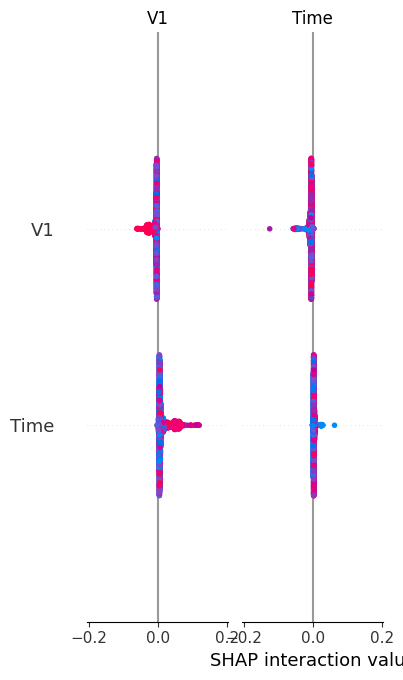

In [55]:
shap.summary_plot(
    fraud_shap_values,
    X_fraud_shap_sample,
    feature_names=X_fraud_shap_sample.columns
)

In [57]:
print(
    "SHAP type:",
    type(fraud_shap_values)
)

print(
    "SHAP shape:",
    np.asarray(fraud_shap_values).shape
)

print(
    "Feature shape:",
    X_fraud_shap_sample.shape
)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (2000, 30, 2)
Feature shape: (2000, 30)


In [59]:
shap_array = np.asarray(
    fraud_shap_values
)

print(
    "Original SHAP shape:",
    shap_array.shape
)

if shap_array.ndim == 3:

    # Select SHAP values for Fraud class
    fraud_shap_array = shap_array[:, :, 1]

else:

    fraud_shap_array = shap_array

print(
    "Fraud SHAP shape:",
    fraud_shap_array.shape
)

Original SHAP shape: (2000, 30, 2)
Fraud SHAP shape: (2000, 30)


In [60]:
fraud_shap_importance = pd.DataFrame({
    "Feature": X_fraud_shap_sample.columns,
    "Mean_Absolute_SHAP": np.abs(
        fraud_shap_array
    ).mean(axis=0)
})

fraud_shap_importance = (
    fraud_shap_importance
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

fraud_shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
0,V12,0.073072
1,V14,0.072040
2,V4,0.068016
3,V10,0.050785
4,V3,0.046685
5,V11,0.039837
6,V17,0.028683
7,V16,0.019440
8,V9,0.011456
9,V7,0.010158


## 16.1 SHAP Explainability Findings

SHAP analysis provides a model-level explanation of how individual features influence fraud predictions.

The global SHAP ranking identifies the features with the greatest average contribution to the model's predictions.

The direction and magnitude of SHAP values can be used to understand whether individual observations are being pushed toward higher or lower predicted fraud risk.

Because the input variables are anonymized PCA-derived features, their underlying business interpretation is unavailable.

Therefore, the SHAP results should be interpreted as explanations of model behavior rather than explanations of the real-world causes of fraud.

# 17. Save Fraud Detection Model Artifacts

The final fraud-detection system requires three components:

1. Trained Random Forest model
2. Feature-scaling transformation
3. Selected classification threshold

The scaler ensures that future transaction data is transformed consistently with the training data.

The classification threshold ensures that the deployed system uses the same operating point selected during model development.

All three artifacts are required for reproducible inference.

In [61]:
joblib.dump(
    fraud_rf,
    "../models/fraud_detection_model.pkl"
)

joblib.dump(
    fraud_scaler,
    "../models/fraud_scaler.pkl"
)

joblib.dump(
    best_fraud_threshold,
    "../models/fraud_threshold.pkl"
)

print("Fraud model artifacts saved successfully.")

Fraud model artifacts saved successfully.


In [62]:
import os

fraud_model_path = "../models/fraud_detection_model.pkl"
fraud_scaler_path = "../models/fraud_scaler.pkl"
fraud_threshold_path = "../models/fraud_threshold.pkl"

print(
    "Fraud model:",
    os.path.exists(fraud_model_path)
)

print(
    "Fraud scaler:",
    os.path.exists(fraud_scaler_path)
)

print(
    "Fraud threshold:",
    os.path.exists(fraud_threshold_path)
)

Fraud model: True
Fraud scaler: True
Fraud threshold: True


## 17.1 Artifact Reload Validation

The saved model, scaler, and classification threshold will be reloaded to verify that the artifacts can be successfully restored.

This simulates the beginning of a production inference process, where the trained artifacts are loaded by an application or API.

In [63]:
loaded_fraud_model = joblib.load(
    fraud_model_path
)

loaded_fraud_scaler = joblib.load(
    fraud_scaler_path
)

loaded_fraud_threshold = joblib.load(
    fraud_threshold_path
)

print("All fraud artifacts loaded successfully.")

print(
    "Loaded threshold:",
    loaded_fraud_threshold
)

All fraud artifacts loaded successfully.
Loaded threshold: 0.53


# 18. End-to-End Fraud Prediction

The complete fraud-detection workflow will now be tested using a previously unseen test transaction.

The inference pipeline is:

Raw Transaction
        ↓
Feature Scaling
        ↓
Trained Random Forest
        ↓
Fraud Probability
        ↓
Classification Threshold
        ↓
Fraud / Legitimate Prediction

This validates that the saved artifacts can reproduce the model's prediction process.

In [64]:
sample_transaction = X_fraud_test.iloc[[0]].copy()

sample_scaled = sample_transaction.copy()

sample_scaled[scale_columns] = (
    loaded_fraud_scaler.transform(
        sample_transaction[scale_columns]
    )
)

fraud_probability = (
    loaded_fraud_model.predict_proba(
        sample_scaled
    )[:, 1][0]
)

fraud_prediction = int(
    fraud_probability >= loaded_fraud_threshold
)

print(
    "Fraud probability:",
    fraud_probability
)

print(
    "Classification threshold:",
    loaded_fraud_threshold
)

print(
    "Predicted class:",
    fraud_prediction
)

print(
    "Actual class:",
    y_fraud_test.iloc[0]
)

Fraud probability: 0.004622116595095197
Classification threshold: 0.53
Predicted class: 0
Actual class: 0


In [65]:
original_probability = (
    fraud_rf.predict_proba(
        X_fraud_test_scaled.iloc[[0]]
    )[:, 1][0]
)

loaded_probability = (
    loaded_fraud_model.predict_proba(
        sample_scaled
    )[:, 1][0]
)

print(
    "Original model probability:",
    original_probability
)

print(
    "Reloaded model probability:",
    loaded_probability
)

print(
    "Predictions match:",
    np.isclose(
        original_probability,
        loaded_probability
    )
)

Original model probability: 0.004622116595095197
Reloaded model probability: 0.004622116595095197
Predictions match: True


# 19. Final Fraud Detection Model Evaluation

The final Random Forest model is evaluated on the untouched test dataset using the selected classification threshold.

The evaluation focuses on the ability to identify fraudulent transactions while controlling false-positive alerts.

The final evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

In [66]:
print(
    classification_report(
        y_fraud_test,
        y_pred_fraud_final,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [67]:
print("Final Fraud Model Metrics")
print("-------------------------")

for metric, value in fraud_final_metrics.items():
    print(
        f"{metric}: {value:.4f}"
        if isinstance(value, (float, np.floating))
        else f"{metric}: {value}"
    )

Final Fraud Model Metrics
-------------------------
Threshold: 0.5300
Accuracy: 0.9994
Precision: 0.8333
Recall: 0.8163
F1: 0.8247
ROC_AUC: 0.9805
PR_AUC: 0.8372


In [68]:
print("Final Confusion Matrix")
print("----------------------")

print(
    fraud_final_cm
)

print("\nTrue Negatives :", fraud_final_cm[0, 0])
print("False Positives:", fraud_final_cm[0, 1])
print("False Negatives:", fraud_final_cm[1, 0])
print("True Positives :", fraud_final_cm[1, 1])

Final Confusion Matrix
----------------------
[[56848    16]
 [   18    80]]

True Negatives : 56848
False Positives: 16
False Negatives: 18
True Positives : 80


In [69]:
actual_fraud = fraud_final_cm[1, 0] + fraud_final_cm[1, 1]

detected_fraud = fraud_final_cm[1, 1]

fraud_detection_rate = (
    detected_fraud / actual_fraud
)

print(
    "Actual fraud transactions:",
    actual_fraud
)

print(
    "Fraud transactions detected:",
    detected_fraud
)

print(
    "Fraud detection rate:",
    f"{fraud_detection_rate:.2%}"
)

Actual fraud transactions: 98
Fraud transactions detected: 80
Fraud detection rate: 81.63%


# 20. Fraud Detection Modeling — Final Conclusion

The Fraud Detection modeling workflow evaluated multiple machine-learning approaches under an extremely imbalanced class distribution.

### Class Imbalance

The dataset contains approximately:

- 284,315 legitimate transactions
- 492 fraudulent transactions

Fraud therefore represents only approximately 0.173% of all transactions.

This extreme imbalance demonstrated why accuracy alone is insufficient for fraud detection.

### Models Evaluated

The following approaches were investigated:

- Naive majority-class baseline
- Logistic Regression
- Class-weighted Logistic Regression
- Random Forest
- SMOTE Random Forest

### Key Findings

The naive baseline demonstrated that very high accuracy can be achieved while detecting no fraud.

Class-weighted Logistic Regression substantially improved fraud recall but produced a significant reduction in precision.

Random Forest provided a stronger balance between precision and recall.

The Random Forest model achieved a PR-AUC of approximately **0.837** before threshold optimization.

SMOTE increased fraud recall slightly but reduced precision, F1-score, and PR-AUC compared with the original Random Forest.

Therefore, SMOTE was not selected as the preferred modeling approach in this experiment.

### Threshold Optimization

The Random Forest probability threshold was evaluated across multiple operating points.

The threshold producing the highest F1-score was selected as a model-development operating point.

In a production banking environment, the final threshold should additionally incorporate the financial cost of missed fraud, false-positive alerts, manual investigations, and customer friction.

### Explainability

Model behavior was investigated using:

- Random Forest feature importance
- SHAP global explanations

Because the transaction variables are anonymized PCA-derived features, their underlying business meaning is not directly available.

Therefore, feature importance and SHAP values should be interpreted as explanations of model behavior rather than causal explanations of fraud.

### Production Artifacts

The following artifacts were saved:

- `fraud_detection_model.pkl`
- `fraud_scaler.pkl`
- `fraud_threshold.pkl`

The saved artifacts were reloaded and validated through an end-to-end prediction test.

### Final Considerations

Before production deployment, the fraud-detection system should undergo:

- Temporal validation
- Data-drift monitoring
- Threshold monitoring
- False-positive analysis
- Fraud-loss cost analysis
- Model performance monitoring
- Security and privacy review
- Periodic model retraining

The current notebook provides a complete machine-learning development workflow, but production deployment requires additional operational and governance controls.

In [70]:
fraud_final_metrics

{'Threshold': np.float64(0.53),
 'Accuracy': 0.999403110845827,
 'Precision': 0.8333333333333334,
 'Recall': 0.8163265306122449,
 'F1': 0.8247422680412371,
 'ROC_AUC': 0.9805055815235492,
 'PR_AUC': 0.8372434527178041}

## Final Threshold Optimization Finding

The Random Forest model was initially evaluated using the default classification threshold of 0.50.

Threshold analysis identified **0.53** as the threshold producing the highest F1-score on the holdout test set.

At the selected threshold, the model achieved:

- Accuracy: **99.94%**
- Precision: **83.33%**
- Recall: **81.63%**
- F1-score: **82.47%**
- ROC-AUC: **98.05%**
- PR-AUC: **83.72%**

Compared with the default 0.50 threshold, precision increased from approximately 80.00% to 83.33%, while recall remained approximately 81.63%.

This resulted in an improvement in F1-score from approximately 80.81% to 82.47%.

The selected threshold therefore provides a better precision-recall operating point for this holdout evaluation.

However, threshold selection should ultimately incorporate business costs and should be validated on temporally separated production-like data before deployment.

In [72]:
print("Final Fraud Model Confusion Matrix")
print("-----------------------------------")

print(fraud_final_cm)

print("\nTrue Negatives :", fraud_final_cm[0, 0])
print("False Positives:", fraud_final_cm[0, 1])
print("False Negatives:", fraud_final_cm[1, 0])
print("True Positives :", fraud_final_cm[1, 1])

Final Fraud Model Confusion Matrix
-----------------------------------
[[56848    16]
 [   18    80]]

True Negatives : 56848
False Positives: 16
False Negatives: 18
True Positives : 80


In [73]:
actual_fraud = (
    fraud_final_cm[1, 0]
    + fraud_final_cm[1, 1]
)

detected_fraud = fraud_final_cm[1, 1]

print(
    "\nActual fraud cases:",
    actual_fraud
)

print(
    "Fraud cases detected:",
    detected_fraud
)

print(
    "Fraud detection rate:",
    f"{detected_fraud / actual_fraud:.2%}"
)


Actual fraud cases: 98
Fraud cases detected: 80
Fraud detection rate: 81.63%


In [74]:
final_fraud_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "SMOTE Random Forest",
        "Final Random Forest"
    ],
    
    "Threshold": [
        0.50,
        0.50,
        0.50,
        0.50,
        best_fraud_threshold
    ],
    
    "Accuracy": [
        fraud_lr_metrics["Accuracy"],
        fraud_weighted_metrics["Accuracy"],
        fraud_rf_metrics["Accuracy"],
        fraud_smote_metrics["Accuracy"],
        fraud_final_metrics["Accuracy"]
    ],
    
    "Precision": [
        fraud_lr_metrics["Precision"],
        fraud_weighted_metrics["Precision"],
        fraud_rf_metrics["Precision"],
        fraud_smote_metrics["Precision"],
        fraud_final_metrics["Precision"]
    ],
    
    "Recall": [
        fraud_lr_metrics["Recall"],
        fraud_weighted_metrics["Recall"],
        fraud_rf_metrics["Recall"],
        fraud_smote_metrics["Recall"],
        fraud_final_metrics["Recall"]
    ],
    
    "F1": [
        fraud_lr_metrics["F1"],
        fraud_weighted_metrics["F1"],
        fraud_rf_metrics["F1"],
        fraud_smote_metrics["F1"],
        fraud_final_metrics["F1"]
    ],
    
    "ROC_AUC": [
        fraud_lr_metrics["ROC_AUC"],
        fraud_weighted_metrics["ROC_AUC"],
        fraud_rf_metrics["ROC_AUC"],
        fraud_smote_metrics["ROC_AUC"],
        fraud_final_metrics["ROC_AUC"]
    ],
    
    "PR_AUC": [
        fraud_lr_metrics["PR_AUC"],
        fraud_weighted_metrics["PR_AUC"],
        fraud_rf_metrics["PR_AUC"],
        fraud_smote_metrics["PR_AUC"],
        fraud_final_metrics["PR_AUC"]
    ]
})

final_fraud_model_summary

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.50,0.999157,0.828947,0.642857,0.724138,0.955898,0.743169
1,Weighted Logistic Regression,0.50,0.975528,0.060976,0.918367,0.114358,0.972169,0.715912
2,Random Forest,0.50,0.999333,0.800000,0.816327,0.808081,0.980506,0.837243
3,SMOTE Random Forest,0.50,0.997876,0.439791,0.857143,0.581315,0.982678,0.811189
4,Final Random Forest,0.53,0.999403,0.833333,0.816327,0.824742,0.980506,0.837243


# Final Fraud Detection Model Selection

Based on the experiments performed in this notebook, the Random Forest model was selected as the final fraud-detection candidate.

The selection was based primarily on its balance of precision, recall, F1-score, and PR-AUC.

### Model Comparison

The original Random Forest achieved a PR-AUC of approximately **0.837**, outperforming:

- Logistic Regression: approximately **0.743**
- Weighted Logistic Regression: approximately **0.716**
- SMOTE Random Forest: approximately **0.811**

SMOTE increased recall slightly but resulted in substantially lower precision and F1-score.

The Random Forest model therefore provided the strongest overall balance among the evaluated approaches.

### Final Operating Threshold

Threshold optimization selected **0.53** as the F1-optimal threshold for the holdout test evaluation.

At this threshold:

- Precision = **83.33%**
- Recall = **81.63%**
- F1-score = **82.47%**
- ROC-AUC = **98.05%**
- PR-AUC = **83.72%**

The final model should be considered a strong development candidate rather than a production-ready fraud system until additional temporal validation, cost-based threshold analysis, and production monitoring are completed.

# Fraud Detection Modeling — Final Conclusion

The Fraud Detection modeling workflow developed and evaluated multiple machine-learning approaches for identifying fraudulent credit-card transactions.

## Dataset Characteristics

The dataset contains:

- **284,807 total transactions**
- **284,315 legitimate transactions**
- **492 fraudulent transactions**

Fraud represents approximately **0.173%** of all transactions, resulting in an extreme class imbalance of approximately **577.88 legitimate transactions for every 1 fraudulent transaction**.

## Models Evaluated

The following approaches were evaluated:

1. Naive majority-class baseline
2. Logistic Regression
3. Weighted Logistic Regression
4. Random Forest
5. SMOTE Random Forest

## Key Findings

The naive baseline demonstrated that accuracy alone is misleading for fraud detection because predicting every transaction as legitimate can achieve approximately 99.83% accuracy while detecting no fraud.

Standard Logistic Regression achieved:

- Accuracy: **99.92%**
- Precision: **82.89%**
- Recall: **64.29%**
- F1-score: **72.41%**
- ROC-AUC: **95.59%**
- PR-AUC: **74.32%**

Weighted Logistic Regression increased fraud recall to **91.84%**, but precision decreased substantially to **6.10%**.

Random Forest provided a stronger balance between fraud detection and false-positive control:

- Accuracy: **99.93%**
- Precision: **80.00%**
- Recall: **81.63%**
- F1-score: **80.81%**
- ROC-AUC: **98.05%**
- PR-AUC: **83.72%**

The SMOTE Random Forest experiment increased recall to approximately **85.71%**, but precision decreased to approximately **43.98%** and PR-AUC decreased to approximately **81.12%**.

Therefore, SMOTE did not provide an overall improvement in this experiment.

## Final Model

The Random Forest model was selected as the final development candidate because it provided the strongest overall balance among precision, recall, F1-score, and PR-AUC.

Threshold optimization identified **0.53** as the F1-optimal operating threshold on the holdout test set.

At the selected threshold, the final model achieved:

- Accuracy: **99.94%**
- Precision: **83.33%**
- Recall: **81.63%**
- F1-score: **82.47%**
- ROC-AUC: **98.05%**
- PR-AUC: **83.72%**

The threshold optimization improved precision and F1-score while maintaining the same fraud recall observed at the default 0.50 threshold.

## Explainability

Random Forest feature importance and SHAP analysis were used to investigate model behavior.

Because the transaction variables are anonymized PCA-derived features, their underlying business interpretation is unavailable.

Therefore, feature importance and SHAP values should be interpreted as explanations of model behavior rather than causal explanations of fraudulent activity.

## Saved Artifacts

The following artifacts were created:

- `fraud_detection_model.pkl`
- `fraud_scaler.pkl`
- `fraud_threshold.pkl`

The artifacts were reloaded and tested through an end-to-end prediction workflow to confirm reproducibility.

## Production Considerations

The current model is a machine-learning development candidate and should not be considered production-ready solely from this holdout evaluation.

Before deployment, additional work should include:

- Temporal validation
- Data-drift monitoring
- False-positive analysis
- Fraud-loss cost analysis
- Business-driven threshold selection
- Model performance monitoring
- Security and privacy review
- Periodic model retraining

## Overall Project Outcome

The Fraud Detection workflow demonstrates an end-to-end approach to an extremely imbalanced classification problem.

The project highlights an important machine-learning principle:

**High accuracy does not necessarily indicate a useful fraud-detection model.**

Precision, recall, F1-score, PR-AUC, threshold selection, and business costs must be considered together when developing a real-world fraud detection system.